# Nonlinear Function Approximation

In [1]:
import torch
import torch.nn as nn
import numpy as np
import plotly.graph_objects as go

## Parametrization of $\mathbb{S}^2$

We can use spherical coordinates to parametrize $\mathbb{S}^2$ in Cartesian coordinates.
\begin{align*}
x &= r \sin(\theta)\cos(\phi)\\
y &= r \sin(\theta)\sin(\phi)\\
z &= r \cos(\theta)
\end{align*}
Since $r=1$ for every point $p\in \mathbb{S}^2$ on the sphere, we need to learn
\begin{align*}
\mathbf{f}(\theta, \phi) =
    \begin{pmatrix}
        \sin(\theta)\cos(\phi)\\
        \sin(\theta)\sin(\phi)\\
        \cos(\theta)
    \end{pmatrix}
\end{align*}

💻 <font color='blue'>**Task A1:** 
Implement a python function, that receives a `torch` tensor, contaiing the angles $\theta$ and $\phi$ as inputs. And returns $\mathbf{f}(\theta,\phi)$ as a tensor.

Do it in such a way that the function can also accept batches of angles and return batches of $\mathbf{f}$.
</font>

In [14]:
def f(angles):
    theta=angles[...,0]
    phi=angles[...,1]
    res = torch.stack([
    torch.sin(theta)*torch.cos(phi),
    torch.sin(theta)*torch.sin(phi),
    torch.cos(theta)
        ],-1)

    return res

## Generating training data

To generate meaningful training data, we have to limit the domain of the angles, i.e., $\theta \in [0,\pi],~\phi \in [0,2\pi)$. Hence we draw $N$ samples from uniform distributions on these intervalls.

In [9]:
N = 100
theta = torch.rand(N) * torch.pi
phi = torch.rand(N) * 2 * torch.pi

The pairs of angles are the input of our training data. The output of the training data is generated by applying the true parametrization $\mathbf{f}$ to the input data.

In [15]:
X = torch.stack([theta, phi], -1)
Y = f(X)
Y.shape

torch.Size([100, 3])

## Creating a neural network

First, we define a class for a simple feef forward neural network.

💻 <font color='blue'>**Task A2:** Fill the gaps to define the class of Feed Forwad Neural Networks.
It should altenate between linear layers and activation layers.
The dimensions of the hidden layers are given by the array `hidden_layers`.
</font>

In [16]:
class FeedForwardNN(nn.Module):
    def __init__(self, input_size, hidden_layers, output_size):
        super().__init__()
        self.activation = nn.Tanh()
        self.input_size = input_size
        self.hidden_layers = hidden_layers
        self.output_size = output_size
        self.__init_net()

    def __init_net(self):
        layers = []
        prev_dim = self.input_size
        for num_neurons in self.hidden_layers:
            layers.append(nn.Linear(prev_dim,num_neurons))
            layers.append(self.activation)
            prev_dim = num_neurons
        layers.append(nn.Linear(prev_dim, self.output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

Now we create an instance of a our feef forward neural network.

The array `hidden_layers` is a hyperparameter that determines depth and width of the neural network.

In [23]:
hidden_layers = [8,10,16]
model = FeedForwardNN(input_size=2, hidden_layers=hidden_layers, output_size=3)
model

FeedForwardNN(
  (activation): Tanh()
  (net): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Tanh()
    (2): Linear(in_features=8, out_features=10, bias=True)
    (3): Tanh()
    (4): Linear(in_features=10, out_features=16, bias=True)
    (5): Tanh()
    (6): Linear(in_features=16, out_features=3, bias=True)
  )
)

## Training

Now that we have a data set as well as a neural network, we want to start the training.

To do this, we need to choose a loss function (here `criterion`), an optimizer (here we choose [Adam](https://arxiv.org/pdf/1412.6980) since it is the most popular one) with a learning rate `lr` and a number of epochs we want to train our neural network `max_epochs`. All of these are hyperparameters that you can tune towards your specific problem.

💻 <font color='blue'>**Task A3:** Choose different hyperparameters and observe how they influence the training.</font>

In [24]:
criterion = nn.MSELoss()
learning_rate = 10**-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
max_epochs = 10**4

for epoch in range(max_epochs+1):
    optimizer.zero_grad()   # reset gradients
    y_pred = model(X)   # make prediction
    loss = criterion(y_pred, Y) # compute loss
    loss.backward()     # compute gradient of the loss wrt. trainable parameters
    optimizer.step()    # make an optimization step

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 0.369035
Epoch 100, Loss: 0.168967
Epoch 200, Loss: 0.085595
Epoch 300, Loss: 0.057428
Epoch 400, Loss: 0.033330
Epoch 500, Loss: 0.019140
Epoch 600, Loss: 0.010550
Epoch 700, Loss: 0.006594
Epoch 800, Loss: 0.005148
Epoch 900, Loss: 0.004352
Epoch 1000, Loss: 0.003738
Epoch 1100, Loss: 0.003208
Epoch 1200, Loss: 0.002741
Epoch 1300, Loss: 0.002335
Epoch 1400, Loss: 0.001997
Epoch 1500, Loss: 0.001726
Epoch 1600, Loss: 0.001510
Epoch 1700, Loss: 0.001333
Epoch 1800, Loss: 0.001181
Epoch 1900, Loss: 0.001045
Epoch 2000, Loss: 0.000922
Epoch 2100, Loss: 0.000811
Epoch 2200, Loss: 0.000711
Epoch 2300, Loss: 0.000624
Epoch 2400, Loss: 0.000547
Epoch 2500, Loss: 0.000482
Epoch 2600, Loss: 0.000426
Epoch 2700, Loss: 0.000379
Epoch 2800, Loss: 0.000339
Epoch 2900, Loss: 0.000306
Epoch 3000, Loss: 0.000276
Epoch 3100, Loss: 0.000251
Epoch 3200, Loss: 0.000229
Epoch 3300, Loss: 0.000209
Epoch 3400, Loss: 0.000192
Epoch 3500, Loss: 0.000177
Epoch 3600, Loss: 0.000163
Epoch 3700, L

## Testing

We want to test the performance of our trained neural network.

To test its extrapolation capabilities, we need to use different data, then the training data.

In [20]:
N_test = 20
theta = torch.rand(N_test) * torch.pi
phi = torch.rand(N_test) * 2 * torch.pi
X_test = torch.stack([theta, phi], -1)
Y_test = f(X_test).detach().numpy()

💻 <font color='blue'>**Task A4:** Perform the forward pass of the Feed Forward Neural Network on `X_test`, store it in a numpy array `pred` and compute the error for each of the test cases.</font>

In [28]:
pred = model(X_test).detach().numpy()
np.linalg.norm(pred-Y_test, axis=-1)

array([0.00900301, 0.00563212, 0.00677608, 0.00617904, 0.00336691,
       0.04311404, 0.02996317, 0.01716018, 0.00341044, 0.00769303,
       0.00814977, 0.0212881 , 0.00887008, 0.0049042 , 0.00458873,
       0.00454979, 0.02635248, 0.00810422, 0.00499507, 0.01169654],
      dtype=float32)

To visualize our results, we create a 3D-plot

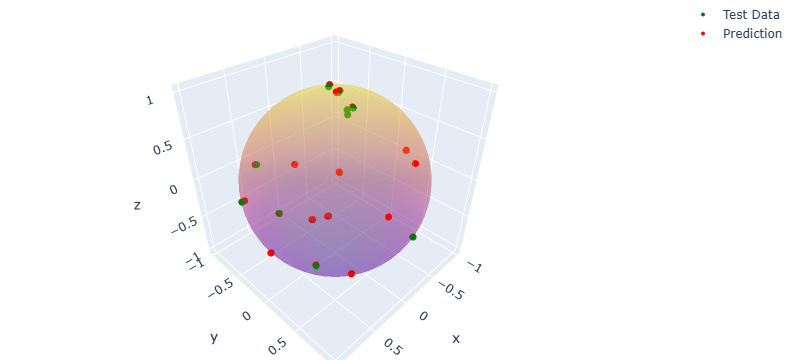

In [29]:
# Create sphere surface
phi = np.linspace(0, np.pi, 50)
theta = np.linspace(0, 2 * np.pi, 50)
phi, theta = np.meshgrid(phi, theta)

r = 1.0  # radius
x = r * np.sin(phi) * np.cos(theta)
y = r * np.sin(phi) * np.sin(theta)
z = r * np.cos(phi)

# Plot
fig = go.Figure()

# Sphere surface
fig.add_surface(x=x, y=y, z=z, opacity=0.3, showscale=False)

# Test data points
fig.add_scatter3d(x=Y_test[...,0], y=Y_test[...,1], z=Y_test[...,2], mode='markers', name="Test Data", marker=dict(size=4, color='green'))

# Prediction data points
fig.add_scatter3d(x=pred[...,0], y=pred[...,1], z=pred[...,2], mode='markers', name = 'Prediction', marker=dict(size=4, color='red'))

fig.update_layout(
    scene=dict(aspectmode="data"),
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

## Penalizing outputs outside of $\mathbb{S}^2$

In general our neural network does not map onto the sphere $\mathbb{S}^2$.

In [31]:
np.abs(np.linalg.norm(pred, axis=-1) - np.ones_like(pred[..., 0]))

array([0.00054544, 0.00468326, 0.00058913, 0.00274843, 0.00313413,
       0.01191175, 0.02892303, 0.01589262, 0.00246799, 0.00577259,
       0.00595963, 0.01127124, 0.00770211, 0.00156224, 0.00363183,
       0.00383031, 0.00791758, 0.00748754, 0.00308883, 0.00105274],
      dtype=float32)

We can try to solve this problem, by penalizing outputs outside of the sphere, i.e., we add a term to the loss function that measures how much the norm differs from 1.

 If we do this we introduce another hyperparameter $\alpha$ that balances the two loss terms.

💻 <font color='blue'>**Task B1:** Code a function `criterion2`. which also penalizes the distance to the sphere.</font>
\begin{align*}
    \mathcal{L}= \Vert x - y \Vert ^2 + \alpha \Vert \small\Vert x \Vert - 1 \normalsize\Vert
\end{align*}

In [34]:
def criterion2(x, y, alpha):
    err_mse = torch.nn.functional.mse_loss(x,y)
    err_nrom = torch.nn.functional.mse_loss(torch.norm(x,-1),torch.ones_like(x[...,0]))
    return err_mse + alpha*err_nrom

Now we train a second model with the same architecture on the same training data set.

In [38]:
alpha = 1
max_epochs = 1000
model2 = FeedForwardNN(input_size=2, hidden_layers=hidden_layers, output_size=3)
for epoch in range(max_epochs+1):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion2(y_pred, Y, alpha)
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

C:\Users\matic\AppData\Local\Temp\ipykernel_7892\2255451587.py:3: UserWarning:

Using a target size (torch.Size([100])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.



Epoch 0, Loss: 0.999417
Epoch 100, Loss: 1.014113
Epoch 200, Loss: 1.033712
Epoch 300, Loss: 1.005812
Epoch 400, Loss: 1.009896
Epoch 500, Loss: 1.010416
Epoch 600, Loss: 1.002765
Epoch 700, Loss: 1.002443
Epoch 800, Loss: 1.008114
Epoch 900, Loss: 1.050324
Epoch 1000, Loss: 1.000874


We test again on the same test data set to have a fair comparison.

We observe that there is a tradeoff between accurary of the approximation and distance to the sphere with this approach.

In [36]:
pred = model(X_test).detach().numpy()
np.linalg.norm(Y_test-pred, axis=-1)

array([0.00900301, 0.00563212, 0.00677608, 0.00617904, 0.00336691,
       0.04311404, 0.02996317, 0.01716018, 0.00341044, 0.00769303,
       0.00814977, 0.0212881 , 0.00887008, 0.0049042 , 0.00458873,
       0.00454979, 0.02635248, 0.00810422, 0.00499507, 0.01169654],
      dtype=float32)

In [37]:
np.abs(np.linalg.norm(pred, axis=-1) - np.ones_like(pred[..., 0]))

array([0.00054544, 0.00468326, 0.00058913, 0.00274843, 0.00313413,
       0.01191175, 0.02892303, 0.01589262, 0.00246799, 0.00577259,
       0.00595963, 0.01127124, 0.00770211, 0.00156224, 0.00363183,
       0.00383031, 0.00791758, 0.00748754, 0.00308883, 0.00105274],
      dtype=float32)

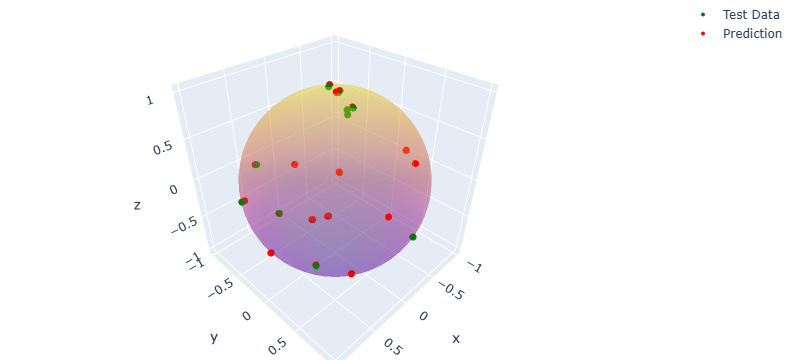

In [39]:
# Plot
fig = go.Figure()

# Sphere surface
fig.add_surface(x=x, y=y, z=z, opacity=0.3, showscale=False)

# Test data points
fig.add_scatter3d(x=Y_test[...,0], y=Y_test[...,1], z=Y_test[...,2], mode='markers', name="Test Data", marker=dict(size=4, color='green'))

# Prediction data points
fig.add_scatter3d(x=pred[...,0], y=pred[...,1], z=pred[...,2], mode='markers', name = 'Prediction', marker=dict(size=4, color='red'))

fig.update_layout(
    scene=dict(aspectmode="data"),
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()